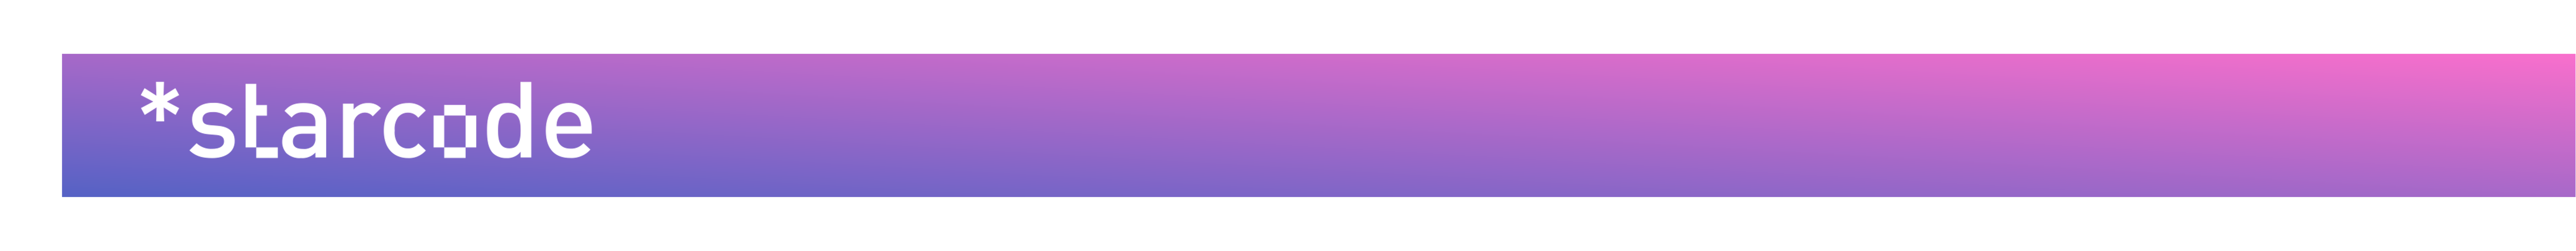


# **<span style="color: #6162C5;">AI with Python</span>  <span style="color: #7865C6;"> - Week 6: Classification </span>** &nbsp; [![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/starcodecourses/Python-KI/PythonKI-V2?labpath=_starcode_Pythonkurs_09.ipynb)


Last week, we learned about regression. This week, we're exploring **classification**, where we aim to categorize objects into different groups/classes. Using characteristics/features of each object, the computer tries to determine which group the object belongs to. For example, we have a model that can tell if a picture shows a cat or a dog. Check it out here: https://teachablemachine.withgoogle.com/models/BVupnxf7L/

## Linear classification
In addition to regression, we can also use lines to classify points. When we have different groups/clusters within a point cloud, drawing a line can help us separate these groups from one another. Consider the following example:

<center><img src="https://cdn.githubraw.com/starcodecourses/Python-Grundlagen-und-KI/PythonKI-V2/_starcode_Pythonkurs_Visuals/linear_classification.png" width="800" /></center>


Imagine you have a scatter plot with two distinct clusters of points. By drawing a straight line between them, you create a boundary that classifies each point based on which side of the line it falls on. This method, known as linear classification, is a simple yet powerful way to organize data into categories.

The points in the plot above could represent a variety of interesting scenarios. Imagine you're a palanetary scientist, and you've created a plot comparing the density to the diameter of various planets. In this plot, two distinct groups emerge: terrestrial planets, like Earth and Mars, which are rocky and dense; and gas giants, like Jupiter and Saturn, which are massive but less dense.

Now, picture this exciting moment: during your latest research, you've discovered a new planet! By placing this new data point on the plot (shown here in red), you can immediately classify this planet into the appropriate group. Does the new planet belong to the cluster with the terrestrial planets or with the gas giants?

A popular algorithm to perform this classification is logistic regression. It operates somewhat like linear regression, but instead of predicting continuous values, it focuses on categorizing data into distinct classes by estimating probabilities using a logistic function. This method effectively maximizes the likelihood of correctly classifying each category by fitting a curve that best separates our groups—like terrestrial planets from gas giants.

<font color='red'>[TODO add animation logisitc regression, image logistic function?]</font>

Let's take a quick look at how this works using the planet classification example, but first, we need to install the libraries we'll be using in this session: NumPy, Matplotlib, and Scikit-learn


In [ ]:
! pip install numpy matplotlib scikit-learn pandas

Now, let's plot the diameters and densities of the planets, and color-code each point according to its class. For this, we'll need lists of diameters and densities, along with a list that categorizes the planet types.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Load data from CSV files for celestial objects: Stars vs Planets
stars = pd.read_csv('/content/drive/MyDrive/Python_KI/W5_Classification/stars.csv', names=["size", "brightness"])
planets = pd.read_csv('/content/drive/MyDrive/Python_KI/W5_Classification/planets.csv', names=["size", "brightness"])

# Data doesn't have labels, we need to add them
stars['label'] = 1
planets['label'] = 0

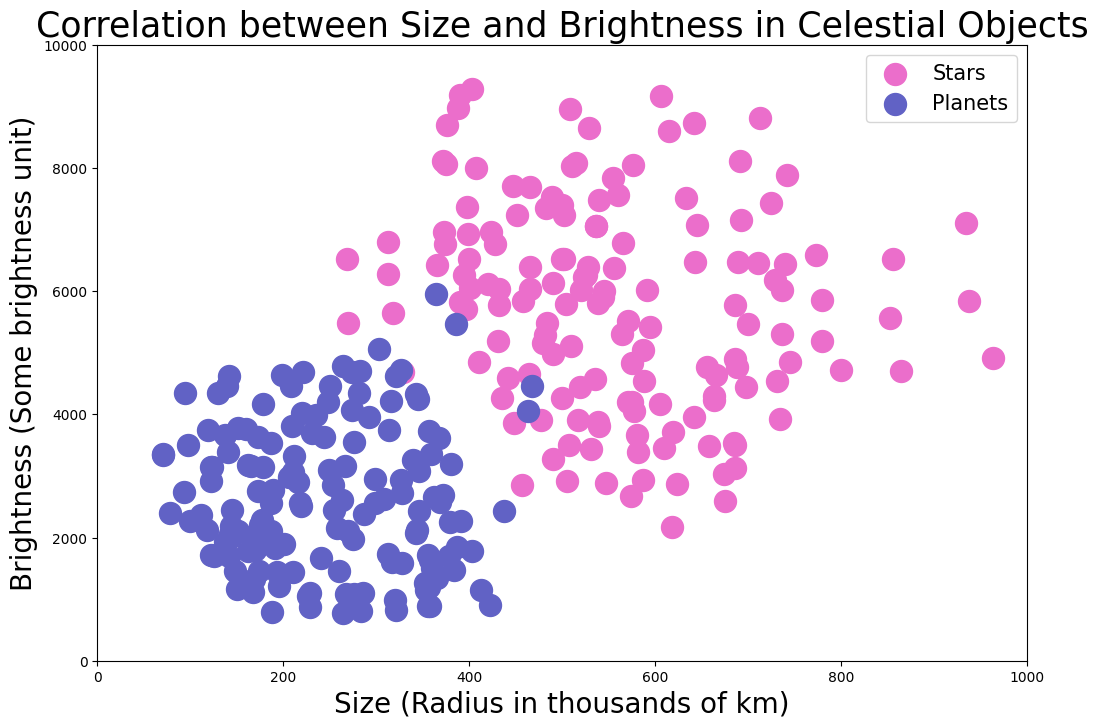

In [ ]:
import matplotlib.pyplot as plt

# Plot data size vs. brightness for stars and planets
plt.figure(figsize=(12,8))
plt.scatter(planets['size'], planets['brightness'], marker='o', s=250, color='#EB6ECB', label='Stars')
plt.scatter(stars['size'], stars['brightness'], marker='o', s=250, color='#6162C5', label='Planets')
plt.title('Correlation between Size and Brightness in Celestial Objects', fontsize=25)
plt.xlabel('Size (Radius in thousands of km)', fontsize=20)
plt.ylabel('Brightness (Some brightness unit)', fontsize=20)
plt.xlim([0, 1000])
plt.ylim([0, 10000])
plt.legend(fontsize=15)
plt.show()


**Interactive Decision Boundary**

Now that we've seen how the planets are distributed based on their diameters and densities, let's explore further with an interactive decision boundary. Below, you'll find sliders that allow you to adjust a linear decision boundary — a line that helps us classify the planets into groups based on the plot.

- **Slope Slider**: This controls the angle of the decision boundary. Adjust it to see how the slope affects the classification of planets.
- **Intercept Slider**: This moves the decision boundary up or down. Experiment with this slider to see how changing the intercept influences which planets fall into each category.

Try adjusting the sliders to align all the rocky planets on one side of the line and all the gas giants on the other. Your goal is to find optimal values for these parameters that clearly separate the two types of planets..


In [ ]:
import matplotlib.pyplot as plt
from ipywidgets import interact, widgets
import numpy as np


def plot_line(slope, intercept):
    plt.figure(figsize=(12,8))

    # Plot data
    plt.scatter(planets['size'], planets['brightness'], marker='o', s=250, color='#EB6ECB', label='Stars')
    plt.scatter(stars['size'], stars['brightness'], marker='o', s=250, color='#6162C5', label='Planets')

    # Plot decision boundary
    x_decision_boundary = np.linspace(0,600)
    y_decision_boundary = slope * x_decision_boundary + intercept
    plt.plot(x_decision_boundary, y_decision_boundary, color='gray', lw=2, ls='--', label='Decision boundary')

    # Add title and labels
    plt.title('Correlation between Size and Brightness in Celestial Objects', fontsize=25)
    plt.xlabel('Size (Radius in thousands of km)', fontsize=20)
    plt.ylabel('Brightness (Some brightness unit)', fontsize=20)
    plt.xlim([0, 1000])
    plt.ylim([0, 10000])
    plt.legend(fontsize=15)
    plt.show()

# Create sliders
interact(plot_line,
         slope=widgets.FloatSlider(min=-30, max=-10, step=1, value=-20),
         intercept=widgets.FloatSlider(min=5000, max=15000, step=1000, value=8000));


interactive(children=(FloatSlider(value=-20.0, description='slope', max=-10.0, min=-30.0, step=1.0), FloatSlid…

**Logistic Regression**

After experimenting with the sliders and manually adjusting the decision boundary, you might wonder if there's a way to automate this process. Indeed, there is! One effective approach is using **logistic regression**, a method that can automatically find the best linear decision boundary based on the data.

Here, we import the `LogisticRegression` class from Scikit-learn's `linear_model` module.

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

Here, we prepare our data for the logistic regression model. We stack the diameters and densities into a single array `X'`, which serves as our input features. The array `y` contains the classifications of each planet as either a rocky planet or a gas giant, serving as our output labels.

We then fit our model using the `.fit()` method. This method takes two parameters: the first is `X` and the second is `y`. By fitting the model to our data, the logistic regression algorithm learns to predict the class of new planets based on their physical characteristics (in our case diameter and density).

In [ ]:
# Reshape data for scikit-learn
# Use X,y or input/output?
data = pd.concat([stars, planets], ignore_index=True)
X = data[['size', 'brightness']]
y = data['label']

# Fit the logistic regression model
model.fit(X, y)

LogisticRegression()

Now, we can compute the slope and intercept of the decision boundary



<details>
<summary style="cursor: pointer; font-weight: bold;"> Details (Click to Expand)</summary>

Given a logistic regression model with the formula:

$$\text{logit}(p) = \beta_0 + \beta_1x_1 + \beta_2x_2$$

where:
- $\beta_0$ is the intercept,
- $\beta_1$ and $\beta_2$ are the coefficients for the features $x_1$ (diameter) and $x_2$ (density) respectively,
- $p$ is the probability of the data point belonging to the positive class (for example, being a gas giant).

The decision boundary occurs where $\text{logit}(p) = 0$, which simplifies to:

$$0 = \beta_0 + \beta_1x_1 + \beta_2x_2$$

Solving for $x_2$ (which you want to plot against $x_1$) gives:

$$x_2 = -\frac{\beta_1}{\beta_2}x_1 - \frac{\beta_0}{\beta_2}$$

Here:
- The slope of the decision boundary is $-\frac{\beta_1}{\beta_2}$,
- The intercept of the decision boundary is $-\frac{\beta_0}{\beta_2}$.
</details>

In [ ]:
# Get trained model coefficients
beta_0 = model.intercept_[0]
beta_1 = model.coef_[0][0]
beta_2 = model.coef_[0][1]

# Calculate the slope and intercept for the decision boundary
slope = -beta_1 / beta_2
intercept = -beta_0 / beta_2

print("Slope of the decision boundary:", slope)
print("Y-intercept of the decision boundary:", intercept)

Slope of the decision boundary: -16.59993954456162
Y-intercept of the decision boundary: 10778.005448563368


This means that we can now draw the decision boundary on our graph to obtain the classification of the data

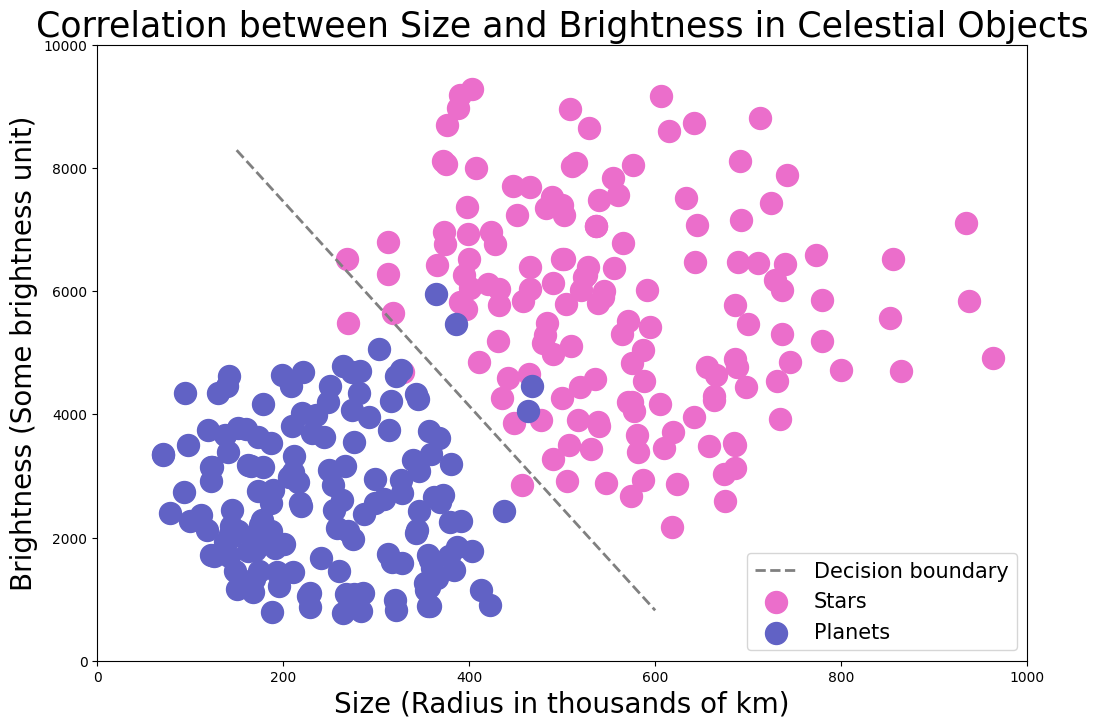

In [ ]:
import numpy as np

x_decision_boundary = np.linspace(150,600)
y_decision_boundary = slope * x_decision_boundary + intercept

plt.figure(figsize=(12,8))

# Plot decision boundary
plt.plot(x_decision_boundary, y_decision_boundary, color='gray', lw=2, ls='--', label='Decision boundary')

# Plot data
plt.scatter(planets['size'], planets['brightness'], marker='o', s=250, color='#EB6ECB', label='Stars')
plt.scatter(stars['size'], stars['brightness'], marker='o', s=250, color='#6162C5', label='Planets')
plt.title('Correlation between Size and Brightness in Celestial Objects', fontsize=25)
plt.xlabel('Size (Radius in thousands of km)', fontsize=20)
plt.ylabel('Brightness (Some brightness unit)', fontsize=20)
plt.xlim([0, 1000])  # Adjust based on your data
plt.ylim([0, 10000])
plt.legend(fontsize=15)
plt.show()

<font color='red'>[TODO add task new planet/star]</font><br>  German text: Du bist eine Astronomin und hast nach langer Suche einen neuen Planeten entdeckt! Du hast herausgefunden, dass der Planet einen Durchmesser von $39348~km$ hat und eine Dichte von $2120~kg/m^3$ hat. Der Planet ist im oberen Plot durch das rote X markiert. Ist dieser Planet ein Gesteinsplanet oder ein Gasplanet?

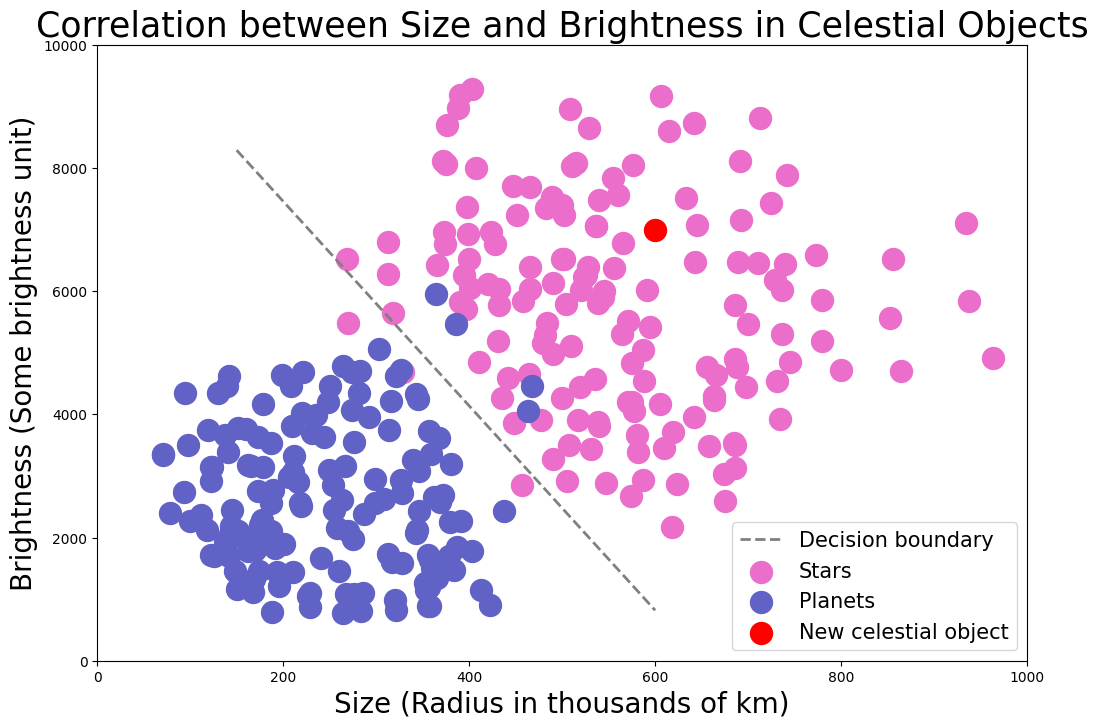

In [ ]:
import numpy as np

x_decision_boundary = np.linspace(150,600)
y_decision_boundary = slope * x_decision_boundary + intercept

plt.figure(figsize=(12,8))

# Plot decision boundary
plt.plot(x_decision_boundary, y_decision_boundary, color='gray', lw=2, ls='--', label='Decision boundary')

# Plot data
plt.scatter(planets['size'], planets['brightness'], marker='o', s=250, color='#EB6ECB', label='Stars')
plt.scatter(stars['size'], stars['brightness'], marker='o', s=250, color='#6162C5', label='Planets')
plt.scatter(600, 7000, marker='o', s=250, color='red', label='New celestial object')
plt.title('Correlation between Size and Brightness in Celestial Objects', fontsize=25)
plt.xlabel('Size (Radius in thousands of km)', fontsize=20)
plt.ylabel('Brightness (Some brightness unit)', fontsize=20)
plt.xlim([0, 1000])  # Adjust based on your data
plt.ylim([0, 10000])
plt.legend(fontsize=15)
plt.show()

## Non linear classification
<font color='red'> [TODO add text]</font><br>
German text: Unser erstes Beispiel für einen Klassifikationsalgorithmus war die Trennung der Klassen durch eine Gerade. Das ist alles schön und gut, aber manchmal gibt es Daten, die nicht einfach durch eine Gerade, Kurve oder sonst welche Form beschrieben werden können. Wir werden uns ein paar solche Fälle unten anschauen. Ein Ansatz, um das dann anzugehen, ist die Nächste-Nachbar-Klassifikation. Hier schaut man, wo der Punkt in unserer Ebene liegt, uns was für Punkte in der Nähe sind. Anhand dieser Information entscheiden wir dann, zu welcher Klasse unser neuer Punkt angehört.

<center><img src="https://drive.google.com/uc?export=view&id=1E5pE6WiDRHF9RBTrXHKRt0GGQC4EZEkh" width="800" /></center>


<font color='red'> [TODO split into tasks and add text]</font><br>


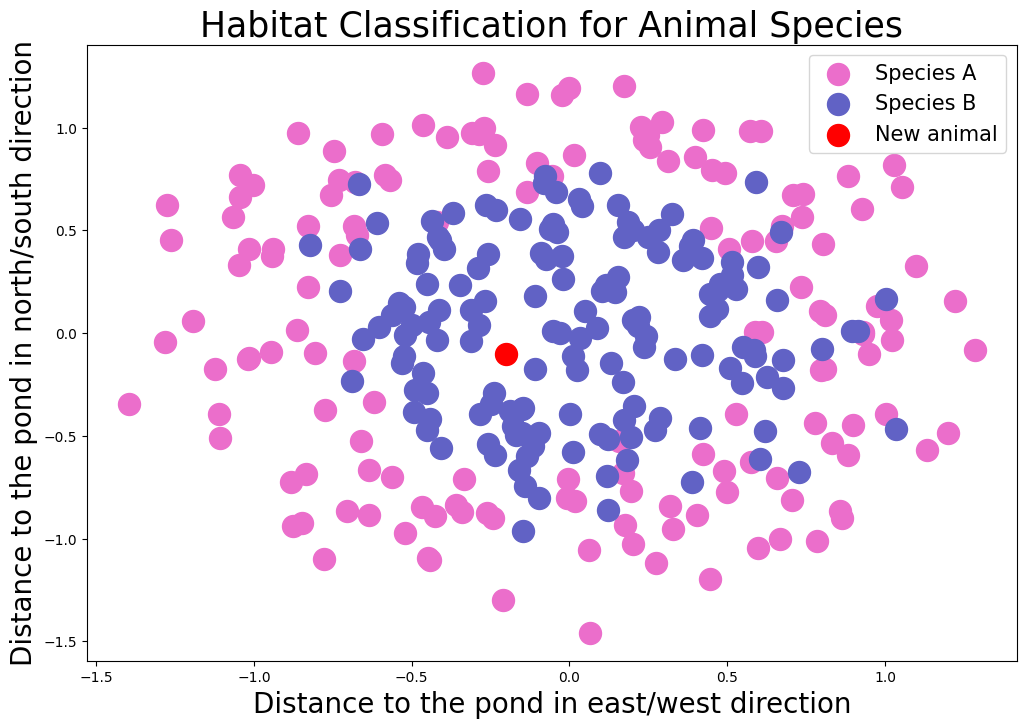

In [4]:
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

# Generate synthetic data
X, y = make_circles(n_samples=300, noise=0.2, factor=0.5, random_state=42)

# Rename features for the ecological context
east_west_distance = X[:, 0]
north_south_distance = X[:, 1]

# Plot the dataset
plt.figure(figsize=(12,8))
plt.scatter(east_west_distance[y == 0], north_south_distance[y == 0], marker='o', s=250, color='#EB6ECB', label='Species A')
plt.scatter(east_west_distance[y == 1], north_south_distance[y == 1], marker='o', s=250, color='#6162C5', label='Species B')
plt.scatter(-0.2, -0.1, marker='o', s=250, color='red', label='New animal')
plt.title('Habitat Classification for Animal Species', fontsize=25)
plt.xlabel('Distance to the pond in east/west direction', fontsize=20)
plt.ylabel('Distance to the pond in north/south direction', fontsize=20)
plt.legend(fontsize=15)
plt.show()




<font color='red'> [TODO change text and add bonus aufgabe]</font><br>


## <span style="color: #9C68C8;">Zusammenfassung</span>
Heute haben wir eine weitere, sehr nützliche Methode zur Klassifikation von Daten kennengelernt, die auch angewendet werden kann, wenn unsere Daten nicht durch einfache Linien getrennt werden können. Diese Methode betrachtet die $k$ nächsten Nachbarn eines Datenpunktes und bestimmt anhand der Mehrheit, welcher Klasse dieser Datenpunkt zugeordnet werden kann! Zudem haben wir auch noch eine Methode kennengelernt, um zu quantifizieren, wie gut unser Datensatz abgeschnitten hat!

